# Notebook 2: Logit Lens
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Vorhersagen nach jeder Schicht visualisieren.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - HuggingFace `output_hidden_states`: https://huggingface.co/docs/transformers/main_classes/output#transformers.modeling_outputs.BaseModelOutputWithPast
> - PyTorch Softmax: https://pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html

## Hintergrund: Was ist der Logit Lens?

Der **Logit Lens** (nostalgebraist, 2020) ist eine Technik, um zu sehen, was ein Transformer "nach jeder Schicht denkt".

**Kernidee:** Transformer haben einen **Residual Stream** — ein Informationskanal, der durch alle Schichten fließt. Jede Schicht *addiert* ihren Beitrag.

Da der finale Output die letzte Projektion des Residual Streams auf den Vokabular-Raum ist, können wir dieselbe **Unembed-Matrix W_U** auch auf frühere Hidden States anwenden:

```
Logit Lens bei Schicht L: logits_L = hidden_state_L @ W_U.T
```

So sehen wir, wie sich die Vorhersage über die Schichten herausbildet.

**Frage:** In welcher Schicht "weiß" das Modell die richtige Antwort?

## 1. Setup und Modell laden

In [2]:
# TODO: Importiere torch, numpy, matplotlib
# TODO: Lade Tokenizer und Modell (wie in Notebook 1)
# 
# MODEL_NAME = "EleutherAI/pythia-410m"
# Fallback: MODEL_NAME = "gpt2-medium"  (bei gpt2-medium: model.lm_head.weight statt model.embed_out.weight)

from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

In [3]:
MODEL_NAME = "EleutherAI/pythia-410m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tokenizer laden
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Modell laden
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",   # wichtig für Attention-Ausgabe
    dtype=torch.float32
)

# Auf Gerät verschieben
model = model.to(device)

# Eval-Modus
model.eval()

print("Modell geladen!")
print("Device:", device)

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Modell geladen!
Device: cuda


## 2. Forward Pass mit Hidden States

In [4]:
clean_prompt = "The movie was good. The sentiment is"
corrupted_prompt = "The movie was terrible. The sentiment is"

# TODO: Tokenisiere beide Prompts
# TODO: Führe einen Forward Pass mit output_hidden_states=True durch
#
#   with torch.no_grad():
#       outputs = model(**inputs, output_hidden_states=True)
#
# TODO: Analysiere outputs.hidden_states:
#   - Wie viele Hidden States gibt es? (Tipp: num_layers + 1, Index 0 = Embedding)
#   - Was ist die Shape jedes Hidden State?
#
# Dokumentation: https://huggingface.co/docs/transformers/main_classes/output
inputs_clean = tokenizer(clean_prompt, return_tensors="pt").to(device)
inputs_corr  = tokenizer(corrupted_prompt, return_tensors="pt").to(device)

# Forward Pass mit Hidden States
with torch.no_grad():
    outputs_clean = model(**inputs_clean, output_hidden_states=True)
    outputs_corr  = model(**inputs_corr, output_hidden_states=True)

# Hidden States holen
hidden_clean = outputs_clean.hidden_states
hidden_corr  = outputs_corr.hidden_states

print("Anzahl Hidden States clean:", len(hidden_clean))
print("Anzahl Hidden States corrupted:", len(hidden_corr))

print("\nClean Hidden State Shapes:")
for i, h in enumerate(hidden_clean):
    print(f"Hidden State {i}: {h.shape}")

print("\nCorrupted Hidden State Shapes:")
for i, h in enumerate(hidden_corr):
    print(f"Hidden State {i}: {h.shape}")



Anzahl Hidden States clean: 25
Anzahl Hidden States corrupted: 25

Clean Hidden State Shapes:
Hidden State 0: torch.Size([1, 8, 1024])
Hidden State 1: torch.Size([1, 8, 1024])
Hidden State 2: torch.Size([1, 8, 1024])
Hidden State 3: torch.Size([1, 8, 1024])
Hidden State 4: torch.Size([1, 8, 1024])
Hidden State 5: torch.Size([1, 8, 1024])
Hidden State 6: torch.Size([1, 8, 1024])
Hidden State 7: torch.Size([1, 8, 1024])
Hidden State 8: torch.Size([1, 8, 1024])
Hidden State 9: torch.Size([1, 8, 1024])
Hidden State 10: torch.Size([1, 8, 1024])
Hidden State 11: torch.Size([1, 8, 1024])
Hidden State 12: torch.Size([1, 8, 1024])
Hidden State 13: torch.Size([1, 8, 1024])
Hidden State 14: torch.Size([1, 8, 1024])
Hidden State 15: torch.Size([1, 8, 1024])
Hidden State 16: torch.Size([1, 8, 1024])
Hidden State 17: torch.Size([1, 8, 1024])
Hidden State 18: torch.Size([1, 8, 1024])
Hidden State 19: torch.Size([1, 8, 1024])
Hidden State 20: torch.Size([1, 8, 1024])
Hidden State 21: torch.Size([1, 8,

## 3. Logit Lens Funktion implementieren

In [5]:
# Forward Pass mit Hidden States

print(outputs_clean.logits.shape)
print(outputs_clean.logits)

test_probs = torch.softmax(outputs_clean.logits[0, -1, :], dim=-1)

top_probs, top_ids = torch.topk(test_probs,10)


for prob, token_id in zip(top_probs, top_ids):

    token_text = tokenizer.decode([token_id.item()])
    print(token_text)
    

torch.Size([1, 8, 50304])
tensor([[[ 1.0606, -3.7054,  3.0022,  ..., -3.7615, -3.7022, -3.7362],
         [ 7.0427, -0.7555, 10.0158,  ..., -0.9154, -0.7901, -0.7918],
         [ 5.0923, -0.6156,  7.3218,  ..., -0.6515, -0.7781, -0.7247],
         ...,
         [ 6.4117, -1.6113,  0.9813,  ..., -1.7185, -1.6124, -1.6427],
         [ 9.0234,  0.8331, 10.2487,  ...,  0.8441,  0.9271,  0.9844],
         [ 7.0543, -0.1799,  5.5512,  ..., -0.1203, -0.1012, -0.0319]]],
       device='cuda:0')
 good
 a
 not
 right
 great
 that
 the
 very
 true
 there


In [106]:
unembed = model.embed_out.weight

print(unembed.T.shape)
print(outputs_clean.hidden_states[0][0,-1,:].shape)

my_test=outputs_clean.hidden_states[0][0,-1,:] @ unembed.T

print(my_test.shape)


torch.Size([1024, 50304])
torch.Size([1024])
torch.Size([50304])


In [7]:
# Die Unembed-Matrix für Pythia:
#   unembed = model.embed_out.weight  # Shape: (vocab_size, hidden_size)
# Für GPT-2 Medium:
#   unembed = model.lm_head.weight

# TODO: Implementiere die Funktion logit_lens(hidden_state, top_k=5):
#   1. Nimm den Hidden State der LETZTEN Token-Position: hidden_state[0, -1, :]
#   2. Berechne die Logits: last_token_hs @ unembed.T
#   3. Wende Softmax an: torch.softmax(logits, dim=-1)
#   4. Berechne Top-K: torch.topk(probs, top_k)
#   5. Dekodiere die Token-IDs: tokenizer.decode([id])
#   6. Gib eine Liste von (token_string, probability) Tupeln zurück
#
# Hinweis: torch.Tensor.detach() löst den Tensor vom Berechnungsgraphen
# Hinweis: @ ist der Matrixmultiplikationsoperator in Python/PyTorch
unembed = model.embed_out.weight  # Shape: (vocab_size, hidden_size)

def logit_lens(hidden_state,top_k=5):
    
    last_token_hs=hidden_state[0,-1,:]
    
    logits =last_token_hs @ unembed.T
    
    probs=torch.softmax(logits,dim=-1)
    
    top_probs, top_ids = torch.topk(probs, top_k)
    
    results = []

    for prob, token_id in zip(top_probs, top_ids):

        token_str = tokenizer.decode([token_id.item()])

        results.append(
            (token_str, prob.item())
        )

    return results
    
    

## 4. Logit Lens über alle Schichten berechnen

In [10]:
# TODO: Iteriere über alle Hidden States (outputs.hidden_states)
#   und rufe logit_lens() für jeden auf.
#
# TODO: Speichere die Ergebnisse in einer Liste und gib eine Tabelle aus:
#   - Layer | Top-1 Token (Clean) | P(Clean) | Top-1 Token (Corrupt) | P(Corrupt)
#
# Frage: Ab welcher Schicht ist " Paris" unter den Top-1-Vorhersagen?
last_hidden = outputs_clean.hidden_states[24]

result = logit_lens(last_hidden,10)

for token, prob in result:
    print(f"{token:15} {prob:.4f}")

 good           0.0594
 a              0.0411
 not            0.0376
 right          0.0343
 great          0.0334
 that           0.0274
 the            0.0266
 very           0.0258
 true           0.0248
 there          0.0225


In [11]:
last_hidden_c = outputs_corr.hidden_states[24]

result = logit_lens(last_hidden_c,10)

for token, prob in result:
    print(f"{token:15} {prob:.4f}")

 not            0.0471
 that           0.0340
 a              0.0322
 so             0.0220
 very           0.0217
 just           0.0216
 the            0.0207
 pretty         0.0185
 really         0.0178
 all            0.0162


## 5. Wahrscheinlichkeit des richtigen Tokens pro Schicht

In [12]:
# TODO: Implementiere get_token_prob_per_layer(outputs, token_id):
#   Gibt für jeden Layer die Wahrscheinlichkeit eines bestimmten Tokens zurück.
#
# correct_token = " Paris"
# correct_tok_id = tokenizer.encode(correct_token)[0]
#
# TODO: Rufe die Funktion für clean und corrupted auf.
# TODO: Erstelle einen Linienchart (plt.plot) mit:
#   - X-Achse: Schicht-Index (0 = Embedding)
#   - Y-Achse: P(" Paris")
#   - Eine Linie für clean, eine für corrupted
#   - Horizontale Linie bei 0.05 als Referenz
#
# Dokumentation plt.plot: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
def get_token_prob_per_layer(outputs, token_id):
    probs_per_layer = []

    for hidden_state in outputs.hidden_states:
        # letzte Token-Position
        last_token_hs = hidden_state[0, -1, :]

        # logits: (vocab_size,)
        logits = last_token_hs @ unembed.T

        # probabilities
        probs = torch.softmax(logits, dim=-1)

        # Wahrscheinlichkeit für bestimmtes Token
        token_prob = probs[token_id].detach().cpu().item()

        probs_per_layer.append(token_prob)

    return probs_per_layer


In [15]:
correct_token = " good"
correct_tok_id = tokenizer.encode(correct_token)[0]

print(correct_token, correct_tok_id)
clean_probs = get_token_prob_per_layer(outputs_clean, correct_tok_id)
corr_probs  = get_token_prob_per_layer(outputs_corr, correct_tok_id)

print("Anzahl Layer clean:", len(clean_probs))
print("Anzahl Layer corrupted:", len(corr_probs))


print(" Layer clean:", clean_probs)
print(" Layer corrupted:", corr_probs)



 good 1175
Anzahl Layer clean: 25
Anzahl Layer corrupted: 25
 Layer clean: [2.0030942323501222e-05, 1.7820633729570545e-05, 2.0267909349058755e-05, 1.976512612600345e-05, 2.4195393052650616e-05, 2.2697930035064928e-05, 2.4698245397303253e-05, 2.8342579753370956e-05, 2.9226395781734027e-05, 4.111448652110994e-05, 3.499195008771494e-05, 3.9762173400959e-05, 4.24459321948234e-05, 5.967861579847522e-05, 0.00013270258205011487, 0.00021609233226627111, 0.0003769777249544859, 0.0012066756607964635, 0.004508618731051683, 0.006886702962219715, 0.011926522478461266, 0.011792092584073544, 0.01595352590084076, 0.020407838746905327, 0.05942954868078232]
 Layer corrupted: [2.0030942323501222e-05, 1.7483034753240645e-05, 1.9904020518879406e-05, 1.9633735064417124e-05, 2.3337170205195434e-05, 2.233320446975995e-05, 2.3453629182768054e-05, 2.7949899958912283e-05, 2.6814344892045483e-05, 3.799821934080683e-05, 3.081186878262088e-05, 3.545410436345264e-05, 3.9758688217261806e-05, 5.1286904636071995e-05, 

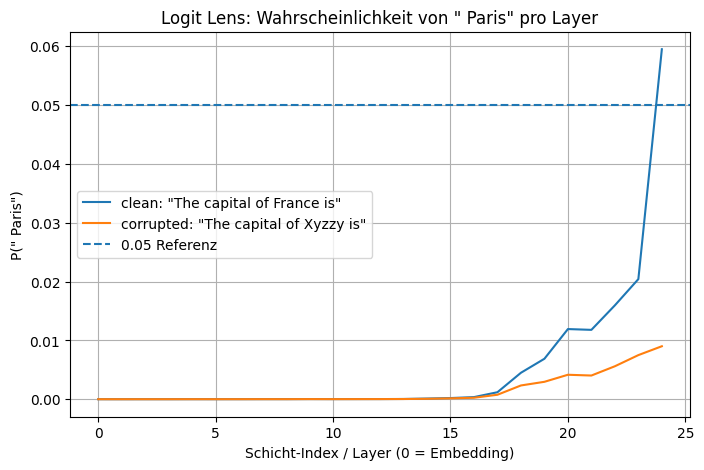

In [16]:
layers = range(len(clean_probs))

plt.figure(figsize=(8, 5))

plt.plot(layers, clean_probs, label='clean: "The capital of France is"')
plt.plot(layers, corr_probs, label='corrupted: "The capital of Xyzzy is"')

plt.axhline(0.05, linestyle="--", label="0.05 Referenz")

plt.xlabel("Schicht-Index / Layer (0 = Embedding)")
plt.ylabel('P(" Paris")')
plt.title('Logit Lens: Wahrscheinlichkeit von " Paris" pro Layer')

plt.legend()
plt.grid(True)
plt.show()

## 6. Heatmap: Top-5 Token je Schicht

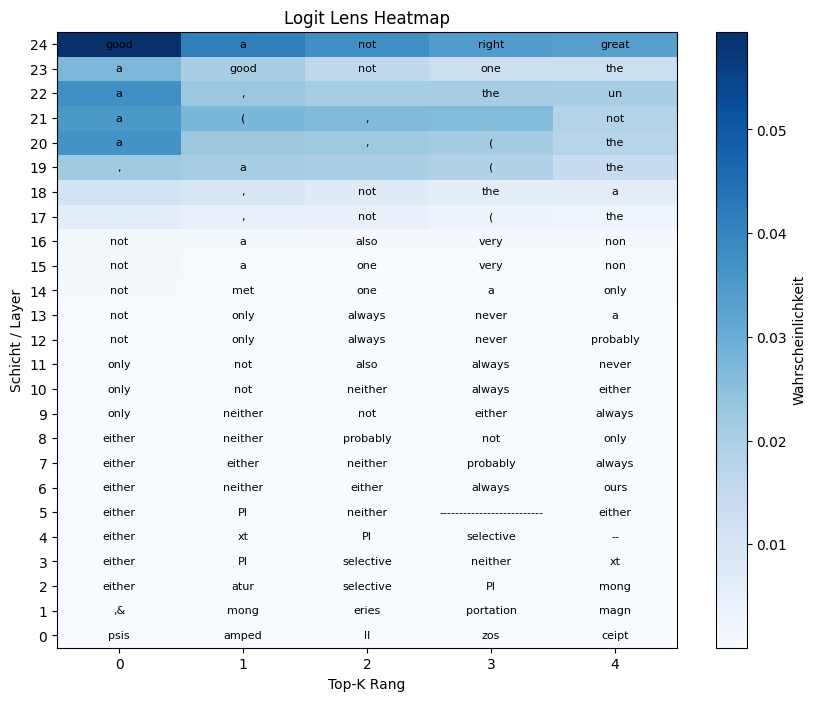

In [17]:
# BONUS: Erstelle eine Heatmap mit plt.imshow():
#   - Y-Achse: Schichten (0 bis n_layers)
#   - X-Achse: Top-K Rang (0 bis 4)
#   - Farbe: Wahrscheinlichkeit des Tokens
#   - Text in jeder Zelle: Token-String (ax.text(...))
#
# Tipp: Erstelle zuerst eine Matrix (n_layers × top_k) mit Wahrscheinlichkeiten
# Tipp: plt.imshow(matrix, cmap="Blues") erstellt die Heatmap
#
# Dokumentation Imshow:
#   https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html


top_k = 5

n_layers = len(outputs_clean.hidden_states)

# Matrix für Wahrscheinlichkeiten
prob_matrix = np.zeros((n_layers, top_k))

# Token-Texte speichern
token_matrix = []

for layer_idx, hidden_state in enumerate(outputs_clean.hidden_states):

    # letzter Hidden State → logits
    last_token_hs = hidden_state[0, -1, :]

    logits = last_token_hs @ unembed.T

    probs = torch.softmax(logits, dim=-1)

    # Top-K
    top_probs, top_ids = torch.topk(probs, top_k)

    layer_tokens = []

    for k in range(top_k):

        prob = top_probs[k].detach().cpu().item()

        token = tokenizer.decode(
            [top_ids[k].item()]
        )

        # Wahrscheinlichkeit speichern
        prob_matrix[layer_idx, k] = prob

        # Token speichern
        layer_tokens.append(token.strip())

    token_matrix.append(layer_tokens)


# Plot
fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(
    prob_matrix,
    cmap="Blues",
    aspect="auto",
    origin="lower"
)

# Achsen
ax.set_xlabel("Top-K Rang")
ax.set_ylabel("Schicht / Layer")

ax.set_xticks(range(top_k))
ax.set_yticks(range(n_layers))

ax.set_title("Logit Lens Heatmap")

# Text in jede Zelle schreiben
for i in range(n_layers):
    for j in range(top_k):

        token = token_matrix[i][j]

        ax.text(
            j,
            i,
            token,
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, label="Wahrscheinlichkeit")

plt.show()

## 7. Reflexionsfragen

In [ ]:
# Beantworte folgende Fragen als Kommentare oder Markdown-Zellen:
#
# 1. In welcher Schicht taucht " Paris" erstmals in den Top-5 auf (Clean)?
# 2. Was passiert bei den frühen Schichten (0-3)?
# 3. Warum bleibt P(" Paris") für den Corrupted-Prompt durchgehend niedrig?
# 4. Was zeigt uns der Logit Lens über den Residual Stream?
#
# Hinweis: Es gibt keine "richtige" Antwort — beschreibe, was du beobachtest.